In [1]:
import open3d as o3d
import open3d.core as o3c
import numpy as np
import matplotlib.pyplot as plt

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/ghanendra/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Tensor from list.
a = o3c.Tensor([0, 1, 2])
print("Created from list:\n{}".format(a))

# Tensor from Numpy.
a = o3c.Tensor(np.array([0, 1, 2]))
print("\nCreated from numpy array:\n{}".format(a))

# Dtype and inferred from list.
a_float = o3c.Tensor([0.0, 1.0, 2.0])
print("\nDefault dtype and device:\n{}".format(a_float))

# Specify dtype.
a = o3c.Tensor(np.array([0, 1, 2]), dtype=o3c.Dtype.Float64)
print("\nSpecified data type:\n{}".format(a))

# Specify device.
a = o3c.Tensor(np.array([0, 1, 2]), device=o3c.Device("CPU:0"))
print("\nSpecified device:\n{}".format(a))

Created from list:
[0 1 2]
Tensor[shape={3}, stride={1}, Int64, CPU:0, 0x5cb12b1c0150]

Created from numpy array:
[0 1 2]
Tensor[shape={3}, stride={1}, Int64, CPU:0, 0x5cb12b0e6360]

Default dtype and device:
[0 1 2]
Tensor[shape={3}, stride={1}, Float64, CPU:0, 0x5cb12b2d1bc0]

Specified data type:
[0 1 2]
Tensor[shape={3}, stride={1}, Float64, CPU:0, 0x5cb12b242f10]

Specified device:
[0 1 2]
Tensor[shape={3}, stride={1}, Int64, CPU:0, 0x5cb12b325060]


In [ ]:
# Shallow copy constructor.
vals = np.array([1, 2, 3])
src = o3c.Tensor(vals)
dst = src
src[0] += 10

# Changes in one will get reflected in other.
print("Source tensor:\n{}".format(src))
print("\nTarget tensor:\n{}".format(dst))

In [3]:
import torch
import torch.utils.dlpack

# From PyTorch
th_a = torch.ones((5,))
o3_a = o3c.Tensor.from_dlpack(torch.utils.dlpack.to_dlpack(th_a))
print(f"th_a: {th_a}")
print(f"o3_a: {o3_a}")
print("")

# Changes to PyTorch array reflects on open3d Tensor and vice versa
th_a[0] = 100
o3_a[1] = 200
print(f"th_a: {th_a}")
print(f"o3_a: {o3_a}")

th_a: tensor([1., 1., 1., 1., 1.])
o3_a: [1 1 1 1 1]
Tensor[shape={5}, stride={1}, Float32, CPU:0, 0x5cb12f3d79c0]

th_a: tensor([100., 200.,   1.,   1.,   1.])
o3_a: [100 200 1 1 1]
Tensor[shape={5}, stride={1}, Float32, CPU:0, 0x5cb12f3d79c0]


## Point Cloud

In [3]:
import open3d as o3d

## Visualize point cloud

In [4]:
print("Load a ply point cloud, print it, and render it")
ply_point_cloud = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)
print(pcd)
print(np.asarray(pcd.points))
o3d.visualization.draw_geometries([pcd],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024])

Load a ply point cloud, print it, and render it
PointCloud with 196133 points.
[[0.65234375 0.84686458 2.37890625]
 [0.65234375 0.83984375 2.38430572]
 [0.66737998 0.83984375 2.37890625]
 ...
 [2.00839925 2.39453125 1.88671875]
 [2.00390625 2.39488506 1.88671875]
 [2.00390625 2.39453125 1.88793314]]


### Voxel downsampling

In [5]:
print("Downsample the point cloud with a voxel of 0.05")
downpcd = pcd.voxel_down_sample(voxel_size=0.05)
o3d.visualization.draw_geometries([downpcd],
                                  zoom=0.3412,
                                  front=[0.4257, 0.2125, 0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024])

Downsample the point cloud with a voxel of 0.05


## Captured Data

In [44]:
pcd = o3d.io.read_point_cloud('test_data/20240430_0_58.ply')
o3d.visualization.draw_geometries([pcd])
print("Downsample the point cloud with a voxel of 0.05")
downpcd = pcd.voxel_down_sample(voxel_size=0.05)
o3d.visualization.draw_geometries([downpcd])

# print("Recompute the normal of the downsampled point cloud")
# downpcd.estimate_normals(
#     search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
# o3d.visualization.draw_geometries([downpcd],point_show_normal=True)

#ply_point_cloud = o3d.data.PLYPointCloud()
#pcd = o3d.io.read_point_cloud(ply_point_cloud.path)

with o3d.utility.VerbosityContextManager(
        o3d.utility.VerbosityLevel.Debug) as cm:
    labels = np.array(
        pcd.cluster_dbscan(eps=0.05, min_points=20, print_progress=True))

max_label = labels.max()
print(f"point cloud has {max_label + 1} clusters")
colors = plt.get_cmap("tab20")(labels / (max_label if max_label > 0 else 1))
colors[labels < 0] = 0
pcd.colors = o3d.utility.Vector3dVector(colors[:, :3])
o3d.visualization.draw_geometries([pcd])

Downsample the point cloud with a voxel of 0.05
[Open3D DEBUG] Precompute neighbors.
[Open3D DEBUG] Done Precompute neighbors.                     ] 2%
[Open3D DEBUG] Compute Clusters
[Open3D DEBUG] Done Compute Clusters: 12
Precompute neighbors.[================>           point cloud has 12 clusters
Precompute neighbors.[========================================] 100%


In [13]:
print("Downsample the point cloud with a voxel of 0.05")
downpcd = pcd.voxel_down_sample(voxel_size=0.05)
o3d.visualization.draw_geometries([downpcd],
                                  zoom=0.3412,
                                  front=[0.4257, 0.2125, 0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024])

Downsample the point cloud with a voxel of 0.05


## Vertex normal estimation

In [29]:
print("Recompute the normal of the downsampled point cloud")
downpcd.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
o3d.visualization.draw_geometries([downpcd],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024],
                                  point_show_normal=True)

Recompute the normal of the downsampled point cloud


## Access estimated vertex normal

In [31]:
print("Print a normal vector of the 0th point")
print(downpcd.normals[0])

Print a normal vector of the 0th point
[-0.27566603 -0.89197839 -0.35830543]


In [32]:
print("Print the normal vectors of the first 10 points")
print(np.asarray(downpcd.normals)[:10, :])

Print the normal vectors of the first 10 points
[[-0.27566603 -0.89197839 -0.35830543]
 [-0.04230441 -0.99410664 -0.09981149]
 [-0.00399871 -0.99965423 -0.02598917]
 [-0.93768261 -0.07378998  0.3395679 ]
 [-0.43476205 -0.62438493 -0.64894177]
 [-0.09739809 -0.9928602  -0.06886388]
 [-0.27498453 -0.67317361 -0.68645524]
 [-0.11728718 -0.95516445 -0.27185399]
 [-0.00816546 -0.99965616 -0.02491762]
 [-0.11067463 -0.99205156 -0.05987351]]


## Crop point cloud

In [33]:
print("Load a polygon volume and use it to crop the original point cloud")
demo_crop_data = o3d.data.DemoCropPointCloud()
pcd = o3d.io.read_point_cloud(demo_crop_data.point_cloud_path)
vol = o3d.visualization.read_selection_polygon_volume(demo_crop_data.cropped_json_path)
chair = vol.crop_point_cloud(pcd)
o3d.visualization.draw_geometries([chair],
                                  zoom=0.7,
                                  front=[0.5439, -0.2333, -0.8060],
                                  lookat=[2.4615, 2.1331, 1.338],
                                  up=[-0.1781, -0.9708, 0.1608])

Load a polygon volume and use it to crop the original point cloud
[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/DemoCropPointCloud.zip
[Open3D INFO] Downloaded to /home/ghanendra/open3d_data/download/DemoCropPointCloud/DemoCropPointCloud.zip
[Open3D INFO] Created directory /home/ghanendra/open3d_data/extract/DemoCropPointCloud.
[Open3D INFO] Extracting /home/ghanendra/open3d_data/download/DemoCropPointCloud/DemoCropPointCloud.zip.
[Open3D INFO] Extracted to /home/ghanendra/open3d_data/extract/DemoCropPointCloud.


## Paint point cloud

In [38]:
print("Paint chair")
chair.paint_uniform_color([0.5, 0.506, 0])
o3d.visualization.draw_geometries([chair],
                                  zoom=0.7,
                                  front=[0.5439, -0.2333, -0.8060],
                                  lookat=[2.4615, 2.1331, 1.338],
                                  up=[-0.1781, -0.9708, 0.1608])

Paint chair


## Point cloud distance

In [39]:
# Load data
demo_crop_data = o3d.data.DemoCropPointCloud()
pcd = o3d.io.read_point_cloud(demo_crop_data.point_cloud_path)
vol = o3d.visualization.read_selection_polygon_volume(demo_crop_data.cropped_json_path)
chair = vol.crop_point_cloud(pcd)

dists = pcd.compute_point_cloud_distance(chair)
dists = np.asarray(dists)
ind = np.where(dists > 0.01)[0]
pcd_without_chair = pcd.select_by_index(ind)
o3d.visualization.draw_geometries([pcd_without_chair],
                                  zoom=0.3412,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[-0.0694, -0.9768, 0.2024])

## Bounding volumes

In [41]:
aabb = chair.get_axis_aligned_bounding_box()
aabb.color = (1, 0, 0)
obb = chair.get_oriented_bounding_box()
obb.color = (0, 1, 0)
o3d.visualization.draw_geometries([chair, aabb, obb],
                                  zoom=0.7,
                                  front=[0.5439, -0.2333, -0.8060],
                                  lookat=[2.4615, 2.1331, 1.338],
                                  up=[-0.1781, -0.9708, 0.1608])

## Convex hull

In [42]:
bunny = o3d.data.BunnyMesh()
mesh = o3d.io.read_triangle_mesh(bunny.path)
mesh.compute_vertex_normals()

pcl = mesh.sample_points_poisson_disk(number_of_points=2000)
hull, _ = pcl.compute_convex_hull()
hull_ls = o3d.geometry.LineSet.create_from_triangle_mesh(hull)
hull_ls.paint_uniform_color((1, 0, 0))
o3d.visualization.draw_geometries([pcl, hull_ls])

[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/BunnyMesh.ply
[Open3D INFO] Downloaded to /home/ghanendra/open3d_data/download/BunnyMesh/BunnyMesh.ply


## DBSCAN clustering

In [47]:
ply_point_cloud = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(ply_point_cloud.path)

with o3d.utility.VerbosityContextManager(
        o3d.utility.VerbosityLevel.Debug) as cm:
    labels = np.array(
        pcd.cluster_dbscan(eps=0.02, min_points=10, print_progress=True))

max_label = labels.max()
print(f"point cloud has {max_label + 1} clusters")
colors = plt.get_cmap("tab20")(labels / (max_label if max_label > 0 else 1))
colors[labels < 0] = 0
pcd.colors = o3d.utility.Vector3dVector(colors[:, :3])
o3d.visualization.draw_geometries([pcd],
                                  zoom=0.455,
                                  front=[-0.4999, -0.1659, -0.8499],
                                  lookat=[2.1813, 2.0619, 2.0999],
                                  up=[0.1204, -0.9852, 0.1215])

[Open3D DEBUG] Precompute neighbors.
[Open3D DEBUG] Done Precompute neighbors.
[Open3D DEBUG] Compute Clusters
[Open3D DEBUG] Done Compute Clusters: 10
Precompute neighbors.[========================================] 100%
Clusteringpoint cloud has 10 clusters              ] 15%


## Plane segmentation

In [51]:
pcd_point_cloud = o3d.data.PCDPointCloud()
pcd = o3d.io.read_point_cloud(pcd_point_cloud.path)

plane_model, inliers = pcd.segment_plane(distance_threshold=0.01,
                                         ransac_n=3,
                                         num_iterations=1000)
[a, b, c, d] = plane_model
print(f"Plane equation: {a:.2f}x + {b:.2f}y + {c:.2f}z + {d:.2f} = 0")

inlier_cloud = pcd.select_by_index(inliers)
inlier_cloud.paint_uniform_color([1.0, 0, 0])
outlier_cloud = pcd.select_by_index(inliers, invert=True)
o3d.visualization.draw_geometries([inlier_cloud, outlier_cloud],
                                  zoom=0.8,
                                  front=[-0.4999, -0.1659, -0.8499],
                                  lookat=[2.1813, 2.0619, 2.0999],
                                  up=[0.1204, -0.9852, 0.1215])

[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/fragment.pcd
[Open3D INFO] Downloaded to /home/ghanendra/open3d_data/download/PCDPointCloud/fragment.pcd
Plane equation: -0.06x + -0.10y + 0.99z + -1.05 = 0


## Hidden Point Removal

In [52]:
print("Convert mesh to a point cloud and estimate dimensions")
armadillo = o3d.data.ArmadilloMesh()
mesh = o3d.io.read_triangle_mesh(armadillo.path)
mesh.compute_vertex_normals()

pcd = mesh.sample_points_poisson_disk(5000)
diameter = np.linalg.norm(
    np.asarray(pcd.get_max_bound()) - np.asarray(pcd.get_min_bound()))
o3d.visualization.draw_geometries([pcd])

Convert mesh to a point cloud and estimate dimensions
[Open3D INFO] Downloading https://github.com/isl-org/open3d_downloads/releases/download/20220201-data/ArmadilloMesh.ply
[Open3D INFO] Downloaded to /home/ghanendra/open3d_data/download/ArmadilloMesh/ArmadilloMesh.ply


In [53]:
print("Define parameters used for hidden_point_removal")
camera = [0, 0, diameter]
radius = diameter * 100

print("Get all points that are visible from given view point")
_, pt_map = pcd.hidden_point_removal(camera, radius)

print("Visualize result")
pcd = pcd.select_by_index(pt_map)
o3d.visualization.draw_geometries([pcd])

Define parameters used for hidden_point_removal
Get all points that are visible from given view point
Visualize result


## RGBD Images

In [2]:
print("Read Redwood dataset")
redwood_rgbd = o3d.data.SampleRedwoodRGBDImages()
color_raw = o3d.io.read_image(redwood_rgbd.color_paths[0])
depth_raw = o3d.io.read_image(redwood_rgbd.depth_paths[0])
rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_raw, depth_raw)
print(rgbd_image)

Read Redwood dataset
RGBDImage of size 
Color image : 640x480, with 1 channels.
Depth image : 640x480, with 1 channels.
Use numpy.asarray to access buffer data.


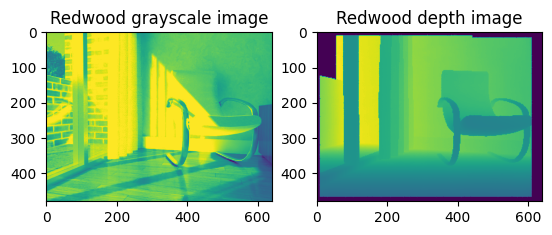

In [3]:
plt.subplot(1, 2, 1)
plt.title('Redwood grayscale image')
plt.imshow(rgbd_image.color)
plt.subplot(1, 2, 2)
plt.title('Redwood depth image')
plt.imshow(rgbd_image.depth)
plt.show()

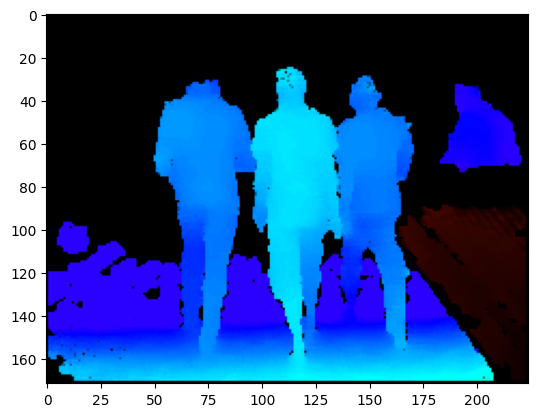

In [10]:
color_img = o3d.io.read_image('color_img.png')
#depth_img = o3d.io.read_image('depth_img.ply')
plt.imshow(color_img)
#plt.imshow(depth_img)
plt.show()

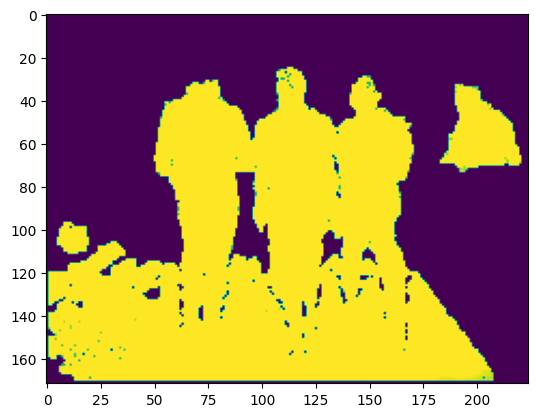

In [51]:
im = np.asarray(color_img)
plt.imshow(im[:,:,2])

In [ ]:
depth_as_img = o3d.geometry.Image(dept)

In [54]:
color_img = o3d.io.read_image('color_img.png')
pcd = o3d.io.read_point_cloud('people_walking.ply')
o3d.io.write_point_cloud('poople_walking_pcd_data.pcd',pcd)
#rgbd_sample_image = o3d.geometry.RGBDImage.create_from_color_and_depth(color_img,im[:,:,2])


True

In [67]:
pcd_data = o3d.io.read_point_cloud('poople_walking_pcd_data.pcd')
o3d.visualization.draw_geometries([pcd_data])

In [63]:
voxel_down_pcd = pcd.voxel_down_sample(voxel_size=0.1)
o3d.visualization.draw_geometries([voxel_down_pcd])
uni_down_pcd = pcd.uniform_down_sample(every_k_points=5)
o3d.visualization.draw_geometries([uni_down_pcd])

In [64]:
def display_inlier_outlier(cloud, ind):
    inlier_cloud = cloud.select_by_index(ind)
    outlier_cloud = cloud.select_by_index(ind, invert=True)

    print("Showing outliers (red) and inliers (gray): ")
    outlier_cloud.paint_uniform_color([1, 0, 0])
    inlier_cloud.paint_uniform_color([0.8, 0.8, 0.8])
    o3d.visualization.draw_geometries([inlier_cloud, outlier_cloud],
                                      zoom=0.3412,
                                      front=[0.4257, -0.2125, -0.8795],
                                      lookat=[2.6172, 2.0475, 1.532],
                                      up=[-0.0694, -0.9768, 0.2024])

In [65]:
print("Statistical oulier removal")
cl, ind = voxel_down_pcd.remove_statistical_outlier(nb_neighbors=20,
                                                    std_ratio=2.0)
display_inlier_outlier(voxel_down_pcd, ind)

Statistical oulier removal
Showing outliers (red) and inliers (gray): 


In [66]:
print("Radius oulier removal")
cl, ind = voxel_down_pcd.remove_radius_outlier(nb_points=16, radius=0.05)
display_inlier_outlier(voxel_down_pcd, ind)

Radius oulier removal
Showing outliers (red) and inliers (gray): 
[Open3D WARNING] The number of points is 0 when creating axis-aligned bounding box.


In [70]:
tetra_mesh, pt_map = o3d.geometry.TetraMesh.create_from_point_cloud(pcd)
for alpha in np.logspace(np.log10(0.5), np.log10(0.01), num=4):
    print(f"alpha={alpha:.3f}")
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(
        pcd, alpha, tetra_mesh, pt_map)
    mesh.compute_vertex_normals()
    o3d.visualization.draw_geometries([mesh], mesh_show_back_face=True)

alpha=0.500
alpha=0.136
alpha=0.037
alpha=0.010


## Working with Numpy

In [71]:
# Generate some neat n times 3 matrix using a variant of sync function
x = np.linspace(-3, 3, 401)
mesh_x, mesh_y = np.meshgrid(x, x)
z = np.sinc((np.power(mesh_x, 2) + np.power(mesh_y, 2)))
z_norm = (z - z.min()) / (z.max() - z.min())
xyz = np.zeros((np.size(mesh_x), 3))
xyz[:, 0] = np.reshape(mesh_x, -1)
xyz[:, 1] = np.reshape(mesh_y, -1)
xyz[:, 2] = np.reshape(z_norm, -1)
print('xyz')
print(xyz)


xyz
[[-3.         -3.          0.17846472]
 [-2.985      -3.          0.17440115]
 [-2.97       -3.          0.17063709]
 ...
 [ 2.97        3.          0.17063709]
 [ 2.985       3.          0.17440115]
 [ 3.          3.          0.17846472]]


In [73]:
#Pass xyz to Open3D.o3d.geometry.PointCloud and visualize
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz)
o3d.io.write_point_cloud("sync.ply", pcd)

True

In [74]:
# Load saved point cloud and visualize it
pcd_load = o3d.io.read_point_cloud("sync.ply")

# Convert Open3D.o3d.geometry.PointCloud to numpy array
xyz_load = np.asarray(pcd_load.points)
print('xyz_load')
print(xyz_load)
o3d.visualization.draw_geometries([pcd_load])

xyz_load
[[-3.         -3.          0.17846472]
 [-2.985      -3.          0.17440115]
 [-2.97       -3.          0.17063709]
 ...
 [ 2.97        3.          0.17063709]
 [ 2.985       3.          0.17440115]
 [ 3.          3.          0.17846472]]


In [76]:
pcd = o3d.io.read_point_cloud('poople_walking_pcd_data.pcd')
o3d.visualization.draw_geometries([pcd])

In [85]:
def custom_draw_geometry_with_camera_trajectory(pcd, render_option_path,

                                                camera_trajectory_path):

    custom_draw_geometry_with_camera_trajectory.index = -1

    custom_draw_geometry_with_camera_trajectory.trajectory =\
    o3d.io.read_pinhole_camera_trajectory(camera_trajectory_path)

    custom_draw_geometry_with_camera_trajectory.vis = o3d.visualization.Visualizer(

    )

    image_path = os.path.join(test_data_path, 'image')

    if not os.path.exists(image_path):

        os.makedirs(image_path)

    depth_path = os.path.join(test_data_path, 'depth')

    if not os.path.exists(depth_path):

        os.makedirs(depth_path)


    def move_forward(vis):

        # This function is called within the o3d.visualization.Visualizer::run() loop

        # The run loop calls the function, then re-render

        # So the sequence in this function is to:

        # 1. Capture frame

        # 2. index++, check ending criteria

        # 3. Set camera

        # 4. (Re-render)

        ctr = vis.get_view_control()

        glb = custom_draw_geometry_with_camera_trajectory

        if glb.index >= 0:

            print("Capture image {:05d}".format(glb.index))

            depth = vis.capture_depth_float_buffer(False)

            image = vis.capture_screen_float_buffer(False)

            plt.imsave(os.path.join(depth_path, '{:05d}.png'.format(glb.index)),

                       np.asarray(depth),

                       dpi=1)

            plt.imsave(os.path.join(image_path, '{:05d}.png'.format(glb.index)),

                       np.asarray(image),

                       dpi=1)

            # vis.capture_depth_image("depth/{:05d}.png".format(glb.index), False)

            # vis.capture_screen_image("image/{:05d}.png".format(glb.index), False)

        glb.index = glb.index + 1

        if glb.index < len(glb.trajectory.parameters):

            ctr.convert_from_pinhole_camera_parameters(

                glb.trajectory.parameters[glb.index], allow_arbitrary=True)

        else:

            custom_draw_geometry_with_camera_trajectory.vis.\
            register_animation_callback(None)

        return False


    vis = custom_draw_geometry_with_camera_trajectory.vis
    vis.create_window()
    vis.add_geometry(pcd)
    vis.get_render_option().load_from_json(render_option_path)
    vis.register_animation_callback(move_forward)
    vis.run()
    vis.destroy_window()